# 📊 Análise Exploratória – NPS Preditivo

O objetivo desta análise é identificar os principais fatores que influenciam a satisfação do cliente em um contexto de e-commerce, utilizando o NPS como métrica central.

A partir dos dados operacionais disponíveis, busca-se entender quais aspectos da jornada impactam negativamente a experiência e como a empresa pode atuar de forma preventiva para reduzir a geração de detratores.

## 🎯 Pergunta de Negócio

Quais fatores operacionais influenciam a satisfação do cliente e como antecipar detratores?

In [38]:
# Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Configuração do estilo dos gráficos
sns.set(style="whitegrid")

In [7]:
# Leitura da base de dados
df = pd.read_csv('desafio_nps_fase_1.csv')

## 📊 Visão Geral da Base

Nesta etapa, exploramos a estrutura da base de dados, tipos de variáveis e estatísticas descritivas.

In [8]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [10]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [11]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [12]:
df.duplicated().sum()

np.int64(0)

## 📊 Como está distribuída a satisfação dos clientes?

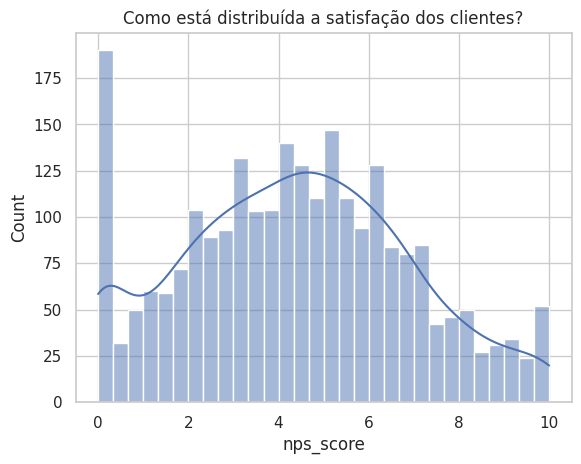

In [13]:
sns.histplot(df['nps_score'], bins=30, kde=True)
plt.title('Como está distribuída a satisfação dos clientes?')
plt.show()

### Análise da distribuição

A distribuição do `nps_score` revela que a maioria dos clientes concentra suas avaliações na faixa intermediária (entre 3 e 7), com pico de frequência próximo de 5. Isso indica que a experiência do cliente é majoritariamente **neutra ou levemente insatisfeita**.

Observa-se ainda:
- **Baixa proporção de promotores** (notas 9–10), o que demonstra dificuldade da empresa em encantar seus clientes.
- **Presença relevante de notas muito baixas** (próximas de 0), sinalizando experiências ruins significativas.

## 📊 Quais variáveis estão correlacionadas com NPS?

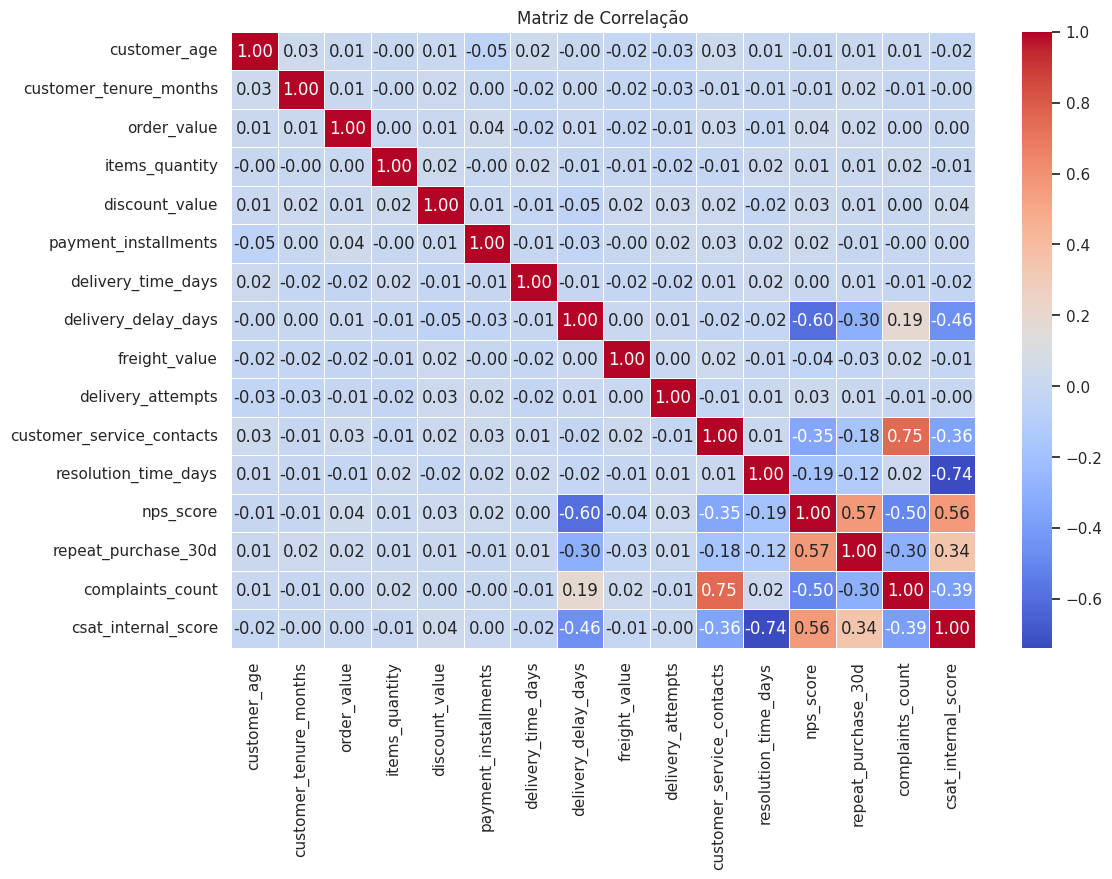

In [14]:
# Excluindo IDs
df_numeric = df.select_dtypes(include=['number']).drop(columns=['customer_id', 'order_id'])

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

In [15]:
# Top correlações com NPS
print(df_numeric.corr()['nps_score'].sort_values(ascending=False))

nps_score                    1.000000
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
items_quantity               0.011468
delivery_time_days           0.000925
customer_tenure_months      -0.009711
customer_age                -0.009936
freight_value               -0.041087
resolution_time_days        -0.191392
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
Name: nps_score, dtype: float64


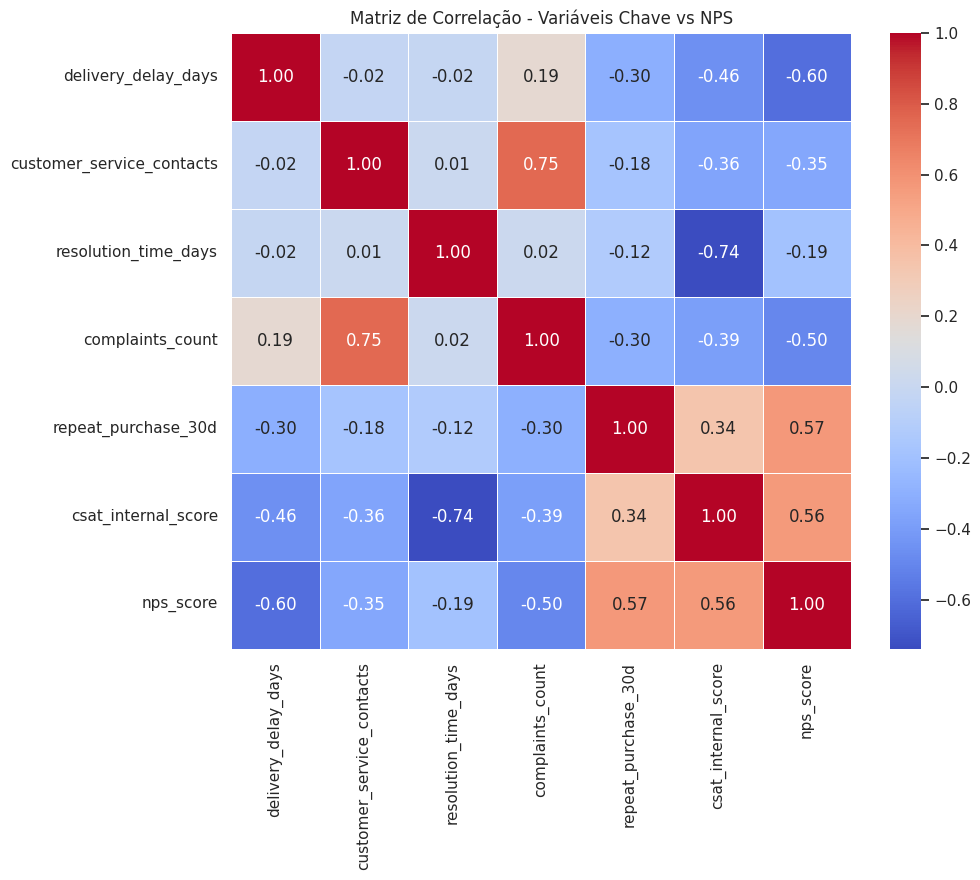

In [16]:
# Matriz de correlação (apenas variáveis relevantes)
cols_relevantes = ['delivery_delay_days', 'customer_service_contacts',
                   'resolution_time_days', 'complaints_count',
                   'repeat_purchase_30d', 'csat_internal_score', 'nps_score']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_relevantes].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Chave vs NPS')
plt.show()

### Análise das correlações

- Existe correlação negativa relevante com as variáveis (delivery_delay_days, complaints_count, customer_service_contacts, resolution_time_days)
- Existe correlação positiva relevante com as variáveis (repeat_purchase_30d, csat_internal_score)

A satisfação do cliente é fortemente impactada por fatores operacionais, especialmente atrasos na entrega, volume de reclamações e necessidade de interação com o atendimento, enquanto características do cliente ou do pedido apresentam baixa influência.

## 📊 Categorizando o NPS

Aplicando boas práticas de mercado, iremos categorizar o NPS seguindo o padrão:

- Detratores: 0 a 6
- Passivos: 7 a 8
- Promotores: 9 a **10**

In [40]:
# Função para categorizar o NPS
def categorizar_nps(x):
    if x <= 6:
        return 'Detrator'
    elif x < 9:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicando a função de categorização
df['nps_class'] = df['nps_score'].apply(categorizar_nps)

### Proporção das categorias de NPS

In [18]:
df['nps_class'].value_counts(normalize=True)

,proportion
nps_class,
Detrator,0.7404
Neutro,0.2156
Promotor,0.0440


### Análise das Categorias

- Detratores: 74,04%
- Neutros: 21,56%
- Promotores: 4,40%

## 📊 Análise das variáveis

#### 🏠 Demográficas



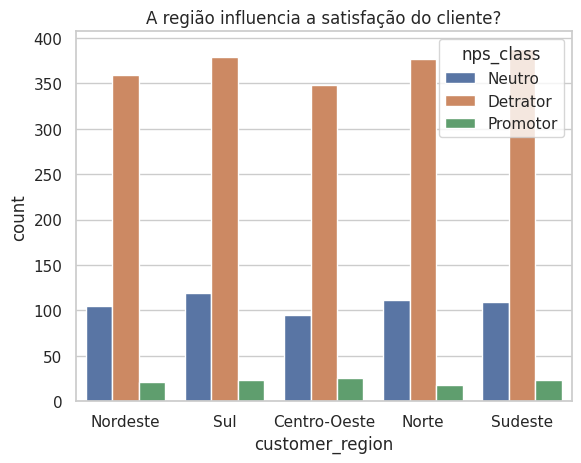

In [19]:
sns.countplot(x='customer_region', hue='nps_class', data=df)
plt.title('A região influencia a satisfação do cliente?')
plt.show()

> A distribuição do NPS entre as regiões apresenta comportamento semelhante, com predominância de clientes detratores em todas as localidades. Não há evidência de que a região geográfica seja um fator determinante para a satisfação do cliente.

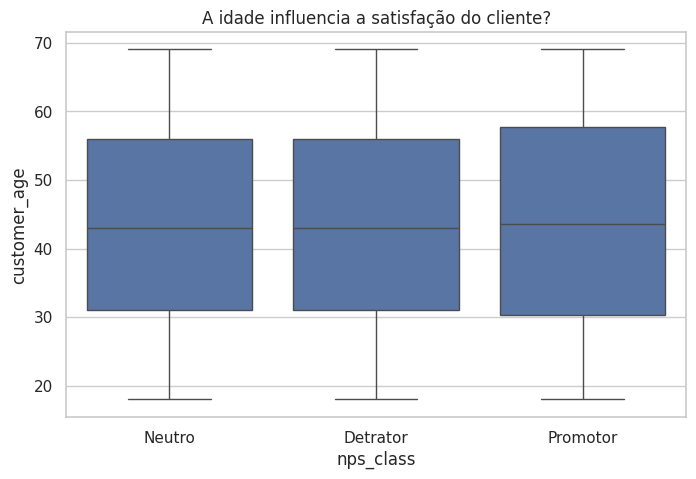

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='customer_age', data=df)
plt.title('A idade influencia a satisfação do cliente?')
plt.show()

> A análise da idade dos clientes não apresenta variações relevantes entre os diferentes níveis de NPS. A distribuição é bastante semelhante entre detratores, neutros e promotores.

##### Análise variáveis demográficas

> As variáveis demográficas não apresentam influência sobre o NPS.

#### 🚚 Logísticas

A logística impacta a satisfação do cliente?

Nesta sessão iremos explorar as variáveis relacionadas à logística da empresa (delivery_attempts, delivery_time_days, freight_value, delivery_delay_days)

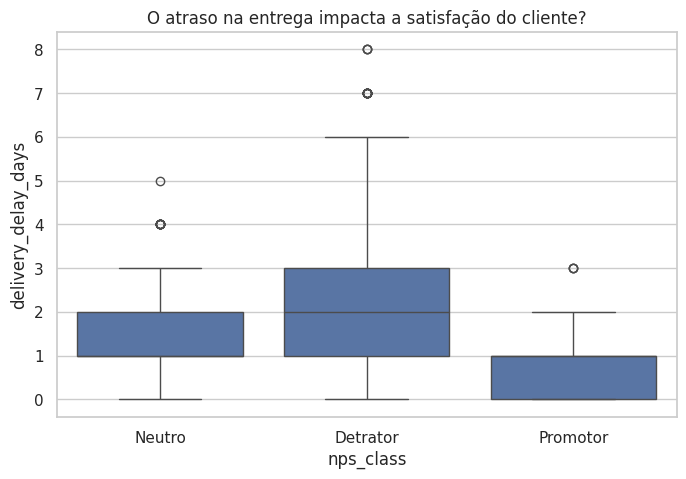

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='delivery_delay_days', data=df)
plt.title('O atraso na entrega impacta a satisfação do cliente?')
plt.show()

> Observa-se que clientes classificados como detratores apresentam, em média, maiores níveis de atraso na entrega, com maior dispersão e presença de casos extremos. Em contrapartida, clientes promotores tendem a apresentar atrasos próximos de zero.

In [41]:
# Segmentação por faixas de dias de atraso
df['delay_group'] = pd.cut(df['delivery_delay_days'],
                          bins=[-1, 0, 2, 5, 10, 100],
                          labels=['Sem atraso', '1-2 dias', '3-5 dias', '6-10 dias', '10+ dias'])

pd.crosstab(df['delay_group'], df['nps_class'], normalize='index')

nps_class,Detrator,Neutro,Promotor
delay_group,,,
Sem atraso,0.364621,0.454874,0.180505
1-2 dias,0.677240,0.277557,0.045202
3-5 dias,0.927552,0.069155,0.003293
6-10 dias,1.000000,0.000000,0.000000


> A análise segmentada do atraso na entrega evidencia um ponto claro de ruptura na experiência do cliente. Pedidos sem atraso apresentam uma distribuição mais equilibrada de NPS, com maior presença de neutros e promotores.

> No entanto, a partir de 1 a 2 dias de atraso, já há um aumento significativo de detratores. Esse efeito se intensifica rapidamente: entre 3 a 5 dias, mais de 90% dos clientes tornam-se detratores, e acima de 6 dias, a totalidade dos clientes avaliados é composta por detratores.

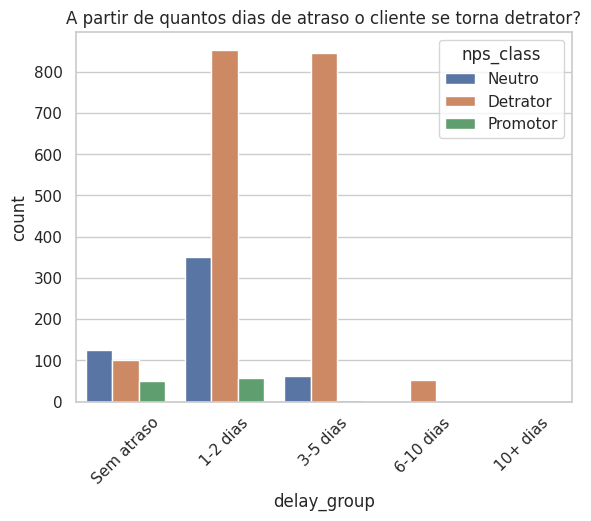

In [23]:
sns.countplot(x='delay_group', hue='nps_class', data=df)
plt.xticks(rotation=45)
plt.title('A partir de quantos dias de atraso o cliente se torna detrator?')
plt.show()

##### 🔴 Insight

> A partir de 3 dias de atraso, mais de 90% dos clientes tornam-se detratores.

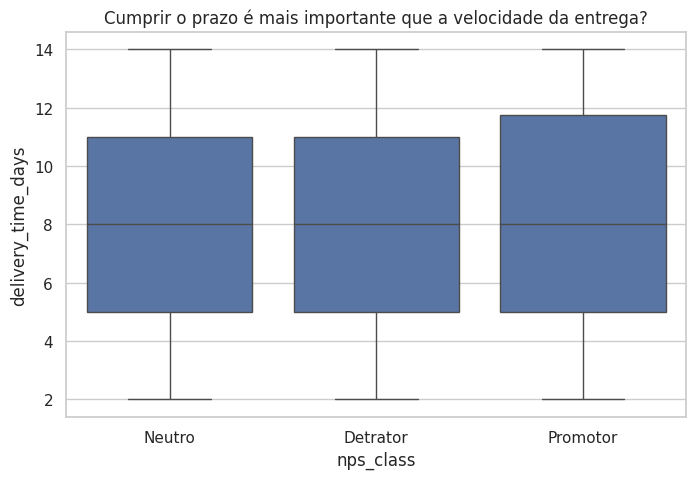

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='delivery_time_days', data=df)
plt.title('Cumprir o prazo é mais importante que a velocidade da entrega?')
plt.show()

> A análise do tempo total de entrega não evidencia diferenças significativas entre os grupos de NPS, apresentando distribuições bastante semelhantes entre detratores, neutros e promotores.

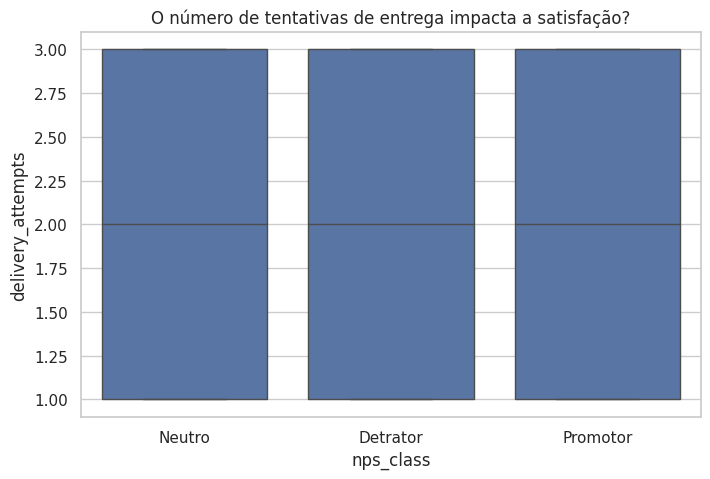

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='delivery_attempts', data=df)
plt.title('O número de tentativas de entrega impacta a satisfação?')
plt.show()

> A análise do número de tentativas de entrega apresenta baixo impacto entre os grupos de NPS, com distribuições bastante semelhantes entre detratores, neutros e promotores.

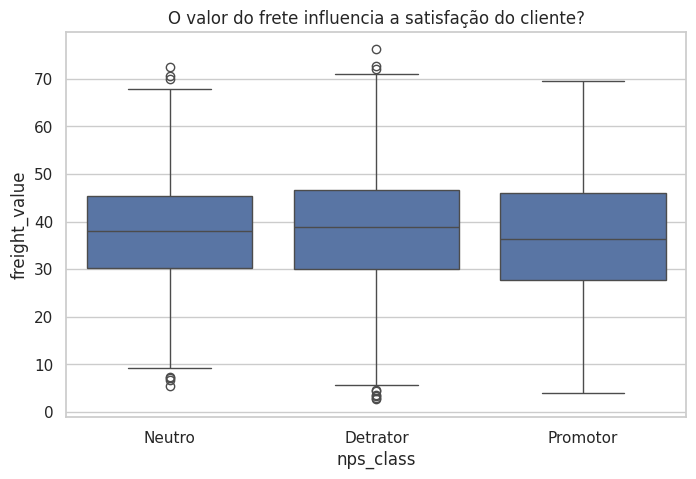

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='freight_value', data=df)
plt.title('O valor do frete influencia a satisfação do cliente?')
plt.show()

> A análise do valor do frete não indica relação significativa com o NPS.

##### Análise variáveis de logísticas

> Variável: delivery_delay_days

>> A distribuição do NPS por faixas de atraso evidencia uma deterioração progressiva da experiência do cliente conforme o atraso aumenta. Pedidos sem atraso apresentam maior equilíbrio entre neutros e promotores, enquanto atrasos de 1 a 2 dias já resultam em predominância de detratores.

>> A partir de 3 dias de atraso, observa-se uma concentração quase total de detratores, eliminando praticamente a presença de promotores. Esse padrão confirma a existência de um ponto crítico na experiência do cliente associado ao atraso na entrega.

> Variáveis: delivery_attempts, delivery_time_days, freight_value

>> Não apresentam influência significativa no NPS

### 📞 Atendimento

O atendimento influencia a satisfação?

Nesta sessão iremos explorar as variáveis relacionadas ao atendimento da empresa (resolution_time_days, customer_service_contacts, complaints_count)

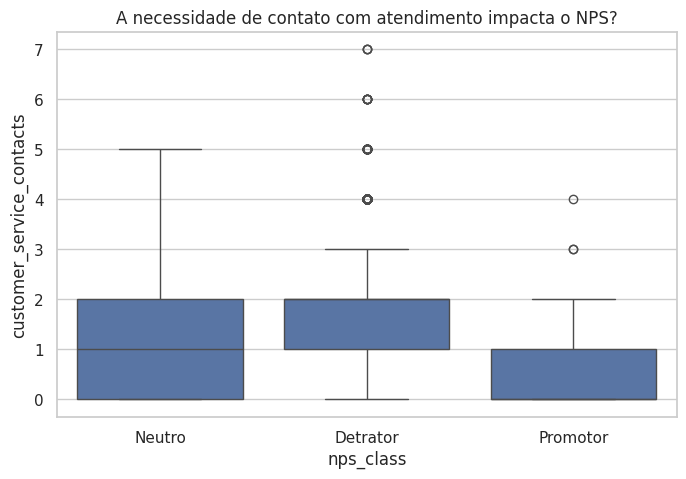

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='customer_service_contacts', data=df)
plt.title('A necessidade de contato com atendimento impacta o NPS?')
plt.show()

Observa-se que clientes detratores apresentam maior número de contatos com o atendimento, incluindo casos com volumes significativamente elevados. Em contrapartida, clientes promotores tendem a ter poucos ou nenhum contato.

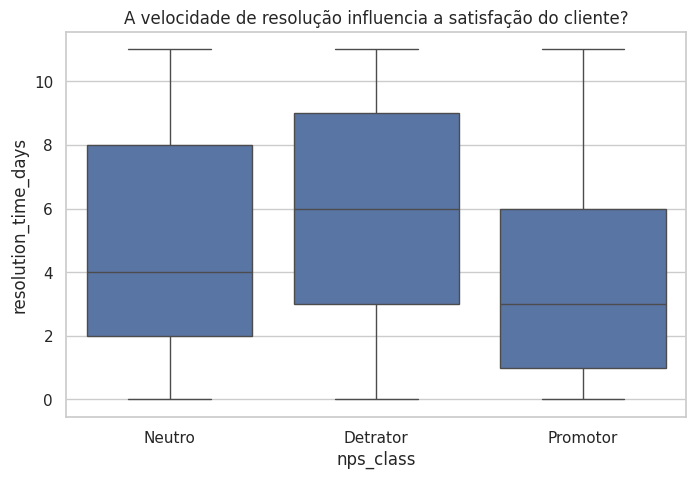

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='resolution_time_days', data=df)
plt.title('A velocidade de resolução influencia a satisfação do cliente?')
plt.show()

Clientes classificados como detratores apresentam, em média, maior tempo de resolução de problemas, enquanto promotores tendem a ter resoluções mais rápidas.

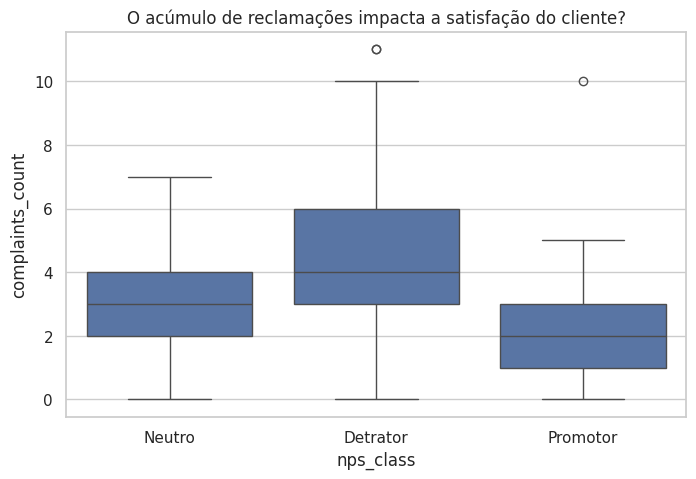

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='complaints_count', data=df)
plt.title('O acúmulo de reclamações impacta a satisfação do cliente?')
plt.show()

Observa-se que clientes detratores apresentam maior número de reclamações, com valores consistentemente superiores aos demais grupos. Em contrapartida, promotores tendem a apresentar baixo volume de reclamações.

##### 🔴 Insight

> A necessidade de acionar o atendimento e o aumento no número de reclamações estão diretamente associados à queda no NPS

##### Análise variáveis de atendimento


As variáveis resolution_time_days, customer_service_contacts, complaints_count influenciam no NPS, notamos que quanto maior a necessidade do cliente de interagir com a empresa, mais ele se torna um detrator.

### 💰 A satisfação impacta a recompra?

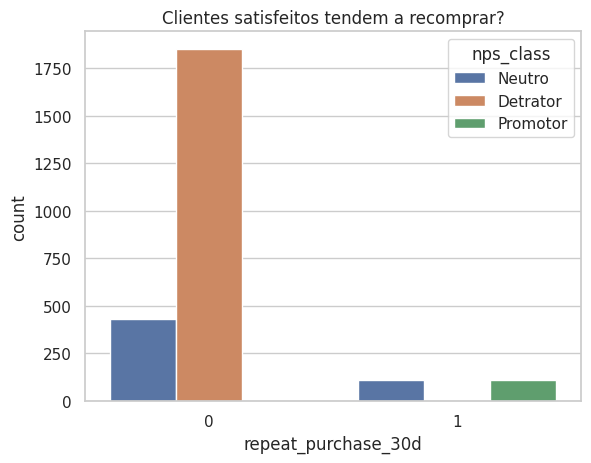

In [30]:
sns.countplot(x='repeat_purchase_30d', hue='nps_class', data=df)
plt.title('Clientes satisfeitos tendem a recomprar?')
plt.show()

In [42]:
pd.crosstab(df['repeat_purchase_30d'], df['nps_class'], normalize='index')

# 0 - NÃO
# 1 - SIM

nps_class,Detrator,Neutro,Promotor
repeat_purchase_30d,,,
0,0.811131,0.188869,0.000000
1,0.000000,0.495413,0.504587


##### Análise recompra

> Não voltaram a comprar:
 >>Detratores: 81,11% | Neutros: 18,88% | Promotores: 0%

> Recompra:  
  >>Detratores: 0% | Neutros: 49,54% | Promotores: 50,45%

> A análise evidencia uma relação direta entre satisfação e recompra. Clientes que não realizaram nova compra apresentam predominância de detratores, enquanto aqueles que efetuaram recompra concentram-se entre neutros e promotores, com forte presença de promotores.

### 📈 O CSAT interno antecipa o NPS?

A análise do CSAT interno permite avaliar se a empresa já possui indicadores capazes de antecipar a satisfação do cliente.

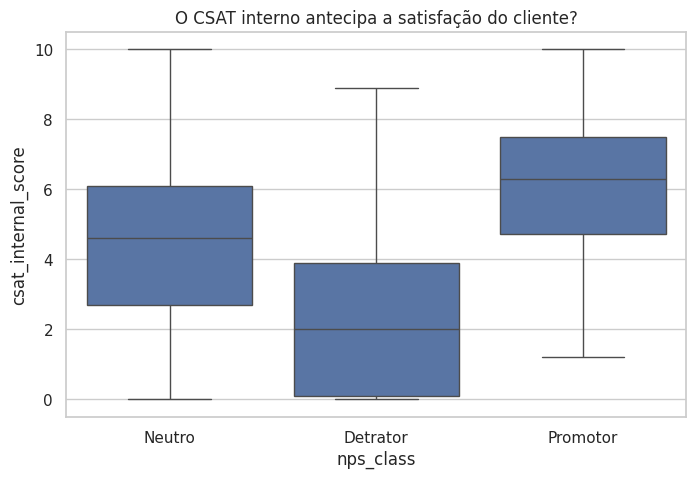

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='csat_internal_score', data=df)
plt.title('O CSAT interno antecipa a satisfação do cliente?')
plt.show()

##### Análise CSAT Interno

Observa-se uma relação consistente entre o CSAT interno e o NPS, onde clientes promotores apresentam maiores níveis de satisfação interna, enquanto detratores concentram os menores valores.

### ⚠️ Variáveis com baixo impacto na satisfação

As seguintes variáveis não apresentaram influência relevante no NPS:

- Tempo de relacionamento
- Valor do pedido
- Desconto aplicado  
- Número de parcelas
- Quantidade de itens
- Idade do cliente (Demográficas)
- Região geográfica (Demográficas)
- Número de tentativas de entrega (Logística)
- Tempo de envio (Logística)
- Valor do frete (Logística)

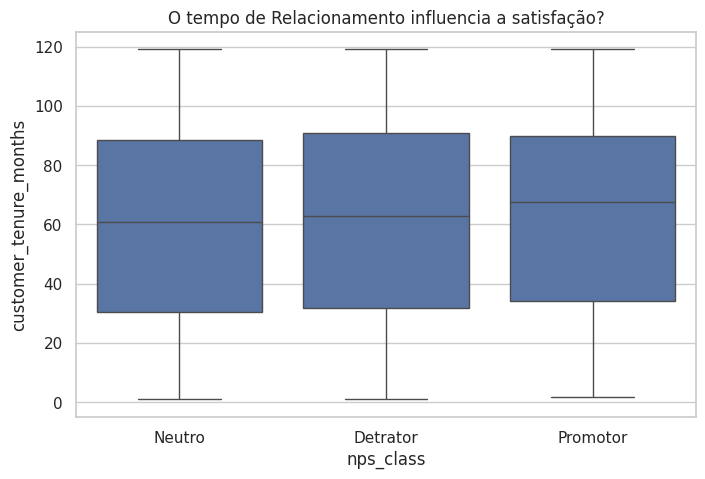

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='customer_tenure_months', data=df)
plt.title('O tempo de Relacionamento influencia a satisfação?')
plt.show()

A análise do tempo de relacionamento com o cliente não apresenta diferenças significativas entre os níveis de NPS, com distribuições semelhantes entre detratores, neutros e promotores.

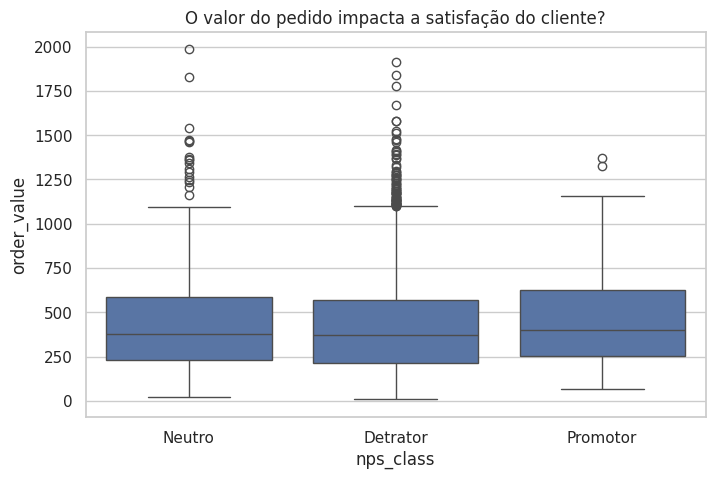

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='order_value', data=df)
plt.title('O valor do pedido impacta a satisfação do cliente?')
plt.show()

A análise do valor do pedido não indica relação significativa com o NPS.

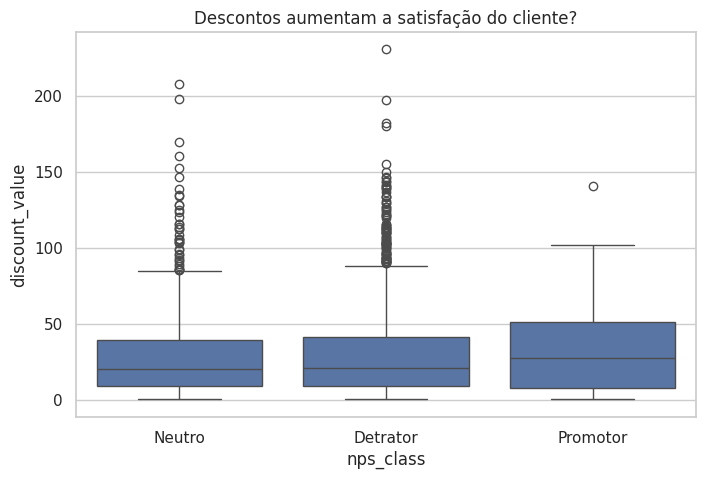

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='discount_value', data=df)
plt.title('Descontos aumentam a satisfação do cliente?')
plt.show()

A análise do valor do desconto não evidencia diferenças significativas entre os níveis de NPS, com distribuições semelhantes entre detratores, neutros e promotores.

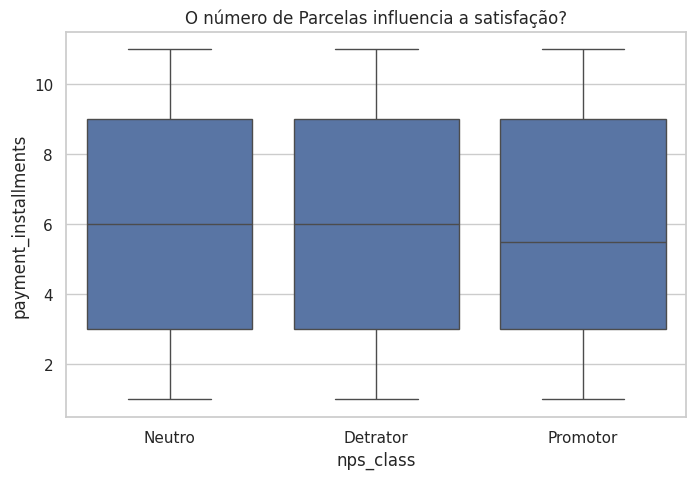

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='payment_installments', data=df)
plt.title('O número de Parcelas influencia a satisfação?')
plt.show()

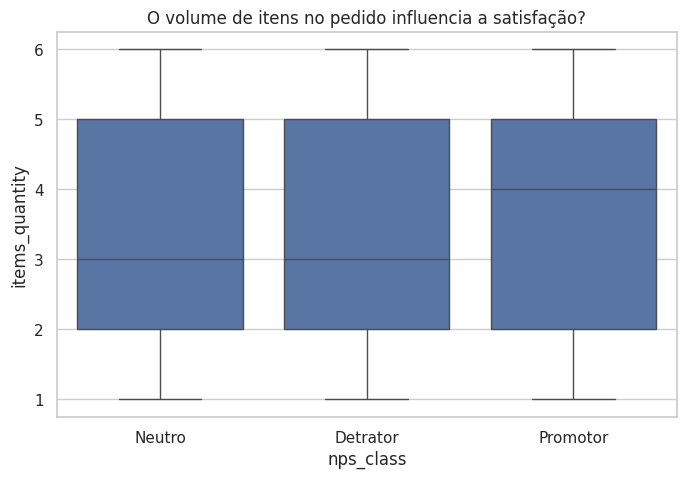

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='nps_class', y='items_quantity', data=df)
plt.title('O volume de itens no pedido influencia a satisfação?')
plt.show()

A análise da quantidade de itens por pedido não indica relação significativa com o NPS, com comportamento semelhante entre os grupos.

##### Análise variáveis com baixo impacto

> A satisfação está mais relacionada à execução operacional do que ao perfil do cliente ou características da compra.

## 🧠 Principais drivers da satisfação (ranking)

1. Atraso na entrega (principal fator)
2. Número de reclamações
3. Contatos com atendimento
4. Tempo de resolução

## 📌 Síntese dos Principais Insights

- **Principal driver**: Atraso na entrega (correlação mais forte negativa).
- **Ponto crítico**: A partir de 3 dias de atraso, a proporção de detratores ultrapassa 90%.

- Além disso, o aumento no número de reclamações, contatos com atendimento e tempo de resolução também está diretamente associado à queda na satisfação.

- A análise exploratória evidencia que a satisfação do cliente é fortemente influenciada por fatores operacionais, especialmente relacionados à logística e ao atendimento.

- Por outro lado, variáveis como idade, região, valor do pedido e descontos não demonstraram impacto relevante no NPS.

- A satisfação está diretamente ligada à recompra

- Esses resultados indicam que a experiência operacional é o principal fator determinante da satisfação do cliente.

## 🚀 Implicações para o Negócio

Com base nos insights obtidos, recomenda-se:

- Priorizar a redução de atrasos na entrega, especialmente evitando atrasos superiores a 2 dias  
- Implementar alertas operacionais para pedidos com risco de atraso  
- Reduzir a necessidade de contato com atendimento, atuando nas causas-raiz dos problemas  
- Melhorar o tempo de resolução de demandas  
- Utilizar o CSAT interno como indicador antecipado de satisfação  

Essas ações podem contribuir diretamente para a redução de detratores e aumento da retenção de clientes.